In [214]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈(Pandas)</font>
- pip install pandas (아나콘다 프롬프트에서)
# 1절. 판다스 패키지
- 데이터 분석을 위해 반드시 알아야할 패키지. 넘파이를 기반으로 하며, 다른 많은 라이브러라와 잘 통합되도록 설계
- 1차원 구조를 갖는 시리즈 / 2차원 구조를 갖는 데이터 프레임을 제공
- 판다스 장점 : 데이터 프레임 생성이 용이, 파일 i/o,레이블링, 부분데이터 추출, 크기변경(행이나 열삽입 삭제),
        데이터 분할, 병합, 데이터 정렬, 결측치 처리, 피벗과 언피벗등이 용이
https://pandas.pydata.org/docs/reference/index.html (API reference)

In [ ]:
#sklearn 머신러닝 이나 전처리 함수 포함되어 있음 결측치 처리 함수도 있다.

In [12]:
import pandas as pd
pd.__version__

'1.5.3'

In [13]:
data=pd.read_json('data/ch09_member1.json',encoding='utf-8')  #encoding='utf-8'판다스 read 함수의기본
print(data)

  name  age    email   address   job
0  홍길동   20  h@h.com   서울시 관악구  None
1  신길동   40  s@h.com  서울시 영등포구    팀장
2  김길동   30  k@h.com   서울시 동작구  None


In [14]:
display(data)
print(type(data))

,name,age,email,address,job
0,홍길동,20,h@h.com,서울시 관악구,None
1,신길동,40,s@h.com,서울시 영등포구,팀장
2,김길동,30,k@h.com,서울시 동작구,None


<class 'pandas.core.frame.DataFrame'>


In [15]:
member4=pd.read_csv('data/ch09_member4.csv') #해더가 있는 csv 파일
member4

,name,age,email,address,job
0,홍길동,20,h@h.com,서울시 관악구,없음
1,신길동,40,s@h.com,서울시 영등포구,팀장
2,김길동,30,k@h.com,서울시 동작구,없음


In [16]:
member1=pd.read_csv('data/ch09_member1.csv', header=None,
                   names=['name','age','email',"addrerss"]) #해더가 없는 csv 파일
member1

,name,age,email,addrerss
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


In [17]:
pd.read_hdf('data/ch09_iris.h5', key='iris')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 2절. 데이터프레임 만들기
## 2.1 딕셔너리를 이용해서 데이터 프레임 만들기


In [18]:
d = {'kor':[100,90],'mat':[95,99]}
d

{'kor': [100, 90], 'mat': [95, 99]}

In [19]:
df= pd.DataFrame(d)
df

,kor,mat
0,100,95
1,90,99


In [20]:
df.to_dict() #데이터프레임을 딕셔너리로

{'kor': {0: 100, 1: 90}, 'mat': {0: 95, 1: 99}}

In [21]:
df.to_numpy()#데이터프레임을 넘파이배열

array([[100,  95],
       [ 90,  99]], dtype=int64)

In [22]:
d = [{'kor':100, 'mat':95.0},
     {'kor':90, 'mat': 99}]
df=pd.DataFrame(d) # 데이터 프레임의 열은 동일 자료형
df

,kor,mat
0,100,95.0
1,90,99.0


In [23]:
df.dtypes # 데이터 프레임의 열별 타입

kor      int64
mat    float64
dtype: object

In [24]:
df.info() # ★ 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kor     2 non-null      int64  
 1   mat     2 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 160.0 bytes


In [25]:
df['kor']

0    100
1     90
Name: kor, dtype: int64

In [26]:
df['kor']=df['kor'].astype('float64') #데이터프레임의 열 타입 변경

In [27]:
df

,kor,mat
0,100.0,95.0
1,90.0,99.0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kor     2 non-null      float64
 1   mat     2 non-null      float64
dtypes: float64(2)
memory usage: 160.0 bytes


In [29]:
d = [{'kor':100, 'mat':100},
     {'kor':90, 'mat':99},
     {'kor':83, 'eng':85}]
df=pd.DataFrame(data=d)        #NaN는 결측치
df

,kor,mat,eng
0,100,100.0,NaN
1,90,99.0,NaN
2,83,NaN,85.0


In [30]:
import numpy as np
type(np.nan) #결측치 타입은 float로 된다.

float

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kor     3 non-null      int64  
 1   mat     2 non-null      float64
 2   eng     1 non-null      float64
dtypes: float64(2), int64(1)
memory usage: 200.0 bytes


In [32]:
# 결측치는 int로 형변환 불가
df['mat'].astype(np.int32)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

## 2.2 리스트를 이용해서 데이터프레임 만들기

In [ ]:
kor = [100, 90, 80, 70, 60]
mat = [90, 80, 81, 71, 61]
df = pd.DataFrame({'kor':kor,'mat':mat})
df

In [ ]:
np.c_[kor,mat]

In [ ]:
df=pd.DataFrame(np.c_[kor,mat], columns=['kor','mat'])

In [126]:
l = [[100,90],[70,80]]
pd.DataFrame(l, columns=['국어','수학'])

,국어,수학
0,100,90
1,70,80


- data.go.kr에서 "상가상권정보" 다운로드 / "민간 아파트 분양가격" 다운로드


In [ ]:
%ls "C:/ai/downloads/shareData/상가정보/""

In [ ]:
df=pd.read_csv('C:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_세종_202603.csv',
              #endcoding='utf-8', sep=','
              nrows=30, # 처음 30행만 가져오기
              low_memory=False
              )

In [ ]:
df.shape

In [33]:
df.head(1) #상위 1행만 출력

,kor,mat,eng
0,100,100.0,NaN


In [34]:
#판다스 디스플레이 옵션
#pd.option.display.max_columns =39 #39열까지 display
#pd.option.display.max_row =30 #30행까지 display

In [35]:
df.head(2).T

,0,1
kor,100.0,90.0
mat,100.0,99.0
eng,NaN,NaN


## 2.3 read_csv                                       26/07/15

In [36]:
#(1) CSV 파일 불러오기(기본값)
member = pd.read_csv('data/ch11_member.csv')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01


In [37]:
member.info() # ★ 중요! 많이 사용하느 명령어

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     6 non-null      object
 1   Age      6 non-null      int64 
 2   Email    6 non-null      object
 3   Address  6 non-null      object
 4   Birth    6 non-null      object
dtypes: int64(1), object(4)
memory usage: 368.0+ bytes


In [38]:
#object -> 숫자 문자 type

In [39]:
#문자형으로 변환  문자형으로 형변환 
member['Age'].astype('str')  #Age는 열이름     파일 수정 안됨

0    20
1    30
2    21
3    22
4    23
5    24
Name: Age, dtype: object

In [40]:
member['Age']= member['Age'].astype('str')  #할당해줘야 원본파일 수정됨
member.Age.dtype

dtype('O')

In [41]:
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     6 non-null      object
 1   Age      6 non-null      object
 2   Email    6 non-null      object
 3   Address  6 non-null      object
 4   Birth    6 non-null      object
dtypes: object(5)
memory usage: 368.0+ bytes


In [42]:
#문자를 숫자로 변환  형변환
member["Age"]

0    20
1    30
2    21
3    22
4    23
5    24
Name: Age, dtype: object

In [43]:
member.loc[0,"Age"] # 문자인걸 확인 했음

'20'

In [44]:
member["Age"].astype('int')     #방법1
import numpy as np
member["Age"].astype(np.int16)  #방법2
pd.to_numeric(member['Age'],    #방법3      숫자로 바꿔줘
              downcast='integer', #빼면 int32나 float64로 자동 변환
              errors='coerce')  #숫자로 바꿀 수 없는 데이터는 결측치로 변환 
                                #ex)3,000 (,)있는건 replace로 콤마 삭제 후 사용해야함
member.dtypes

Name       object
Age        object
Email      object
Address    object
Birth      object
dtype: object

In [45]:
#문자로 읽어드린 birth를 datetime형으로
#01-01-1999      19990101 타입으로 되어 있을땐 astype 사용
member.loc[0,'Birth']  
member['Birth']=member['Birth'].astype('datetime64[ns]')
member=member.astype({'Birth':'datetime64[ns]','Age':'int32'})
member['Birth']=pd.to_datetime(member['Birth'],
              format='%Y-%m-%d %H:%M:%S') 
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     6 non-null      object        
 1   Age      6 non-null      int32         
 2   Email    6 non-null      object        
 3   Address  6 non-null      object        
 4   Birth    6 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int32(1), object(3)
memory usage: 344.0+ bytes


In [46]:
member.Birth.dt.year  # 연도만 뽑을 수 있다

0    1999
1    1999
2    1999
3    1999
4    1999
5    2000
Name: Birth, dtype: int64

In [47]:
member['year']=member.Birth.dt.year
member['month']=member.Birth.dt.month
member['day']=member.Birth.dt.day
member

,Name,Age,Email,Address,Birth,year,month,day
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1


In [48]:
current_date=pd.to_datetime('2026-07-15')
member['일수']= (current_date - member.Birth).dt.days
member

,Name,Age,Email,Address,Birth,year,month,day,일수
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1,10057
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1,9723
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1,9753
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1,9937
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30,10028
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1,9692


In [49]:
#(2)특정행을 제외하고 cp949 encoding 파일 읽어오기                      #cp949의 장점은 excel에서 열림
member = pd.read_csv('data/ch11_membercp949.csv',
                     encoding='cp949',
                     skiprows=[1, 6])  #1,6행 제외하고 읽기
member

,Name,Age,Email,Address,Birth
0,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
1,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
2,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
3,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [50]:
# (3) sep='|', 주석(#)제외, 상위 몇행만, datetime형 필드 지정 
#하이픈으로 분리된 파일(컴마로 분류되지 않은 파일 and #으로 된 파일도 가져오지마)
member_df = pd.read_csv('data/ch11_membersep.csv',
                         sep="|",                # |기준으로 데이터를 분리해서 읽기
                         comment="#",            # 주석제외  #이 있는 행은 제외하고 읽기
                         nrows=3,                #상위3줄만 읽기
                         parse_dates=['Birth'])  #datetime 형으로 읽어올 필드지정
member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [51]:
member_df2=pd.read_csv('data/ch11_membertab.csv',
                        sep="\t",
                        comment="#",
                        parse_dates=['Birth'])

print(member_df2['Birth'].dtype)
display(member_df2)

datetime64[ns]


,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 2.4 패키지에서 가져오기 : iris 데이터
- iris 가져오기 방법1 : sklearn( 머신러닝 패키지 )
- iris 가져오기 방법2 : statsmodels ( R 데이터 )
- iris 가져오기 방법3 : seaborn ( 시각화 패키지 )

### 2.4.1 iris 방법1 : sklearn
- sklearn.datasets 모듈 데이터(iris)를 데이터프레임으로 변환 

#####

In [52]:
from sklearn import datasets
#import sklearn,datasets as datesets  #: 머신러닝을 공부하기 위한 학습용 데이터 셋을 제공
# sklearn의 패키지의 데이터셋: 독립변수(입력변수)와 종속변수(타겟변수)가 분리된 딕셔너리 형태로 제공
iris=datasets.load_iris() # 딕셔너리 형태
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [53]:
print(iris.DESCR) # iris 데이터셋에 대한 설명

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [54]:
iris.data # 독립변수
iris['data'][:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [55]:
import pandas as pd
pd.DataFrame(iris.data)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [56]:
iris.feature_names  #독립변수의 열이름  이름속에 스페이스바가 있어 수정필요
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [57]:
#데이터프레임에서 열이름(독립변수)
[col[:-5] for col in iris.feature_names]  #(cm) 빼기

['sepal length', 'sepal width', 'petal length', 'petal width']

In [58]:
[col[:12].strip() for col in iris.feature_names]  # 위와 같은 방식

['sepal length', 'sepal width', 'petal length', 'petal width']

In [59]:
[col[:-5].replace(" ","_") for col in iris.feature_names]  # 스페이스를 언더바로 바꿔

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [60]:
#종속변수(타겟변수)
iris.target
iris['target']  #위와 같음

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [61]:
iris.target_names
iris[target_names] #위와 같음

NameError: name 'target_names' is not defined

In [62]:
#데이터프레임에 가장 오른쪽 열(타겟변수)
iris.target_names[iris.target]        
iris['target_names'][iris['target']] # 위와 같음

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [63]:
#독립변수
data = iris.data
print(data[::50])   #50번째마다 데이터 출력
#종속변수
target=iris.target_names[iris.target].reshape(-1,1)
print(target[::50])  #50번째마다 데이터 출력

[[5.1 3.5 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.3 3.3 6.  2.5]]
[['setosa']
 ['versicolor']
 ['virginica']]


In [64]:
print('독립변수의 차원 :',data.shape)
print('종속변수의 차원 :',target.shape)

독립변수의 차원 : (150, 4)
종속변수의 차원 : (150, 1)


In [65]:
# (방법a) 독립변수, 종속변수를 stack한 후, 데이터 프레임으로 생성
import numpy as np
df=pd.DataFrame(np.hstack((data,target)),
                columns= [col[:-5].replace(" ","_") for col in iris.feature_names] +['species'])  # head 추가   
df.head(3) #상위 3행만

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [66]:
df['petal_width']      #원하는 특정 열만 가져오기
df.petal_width[:3]

0    0.2
1    0.2
2    0.2
Name: petal_width, dtype: object

In [67]:
df.species[::50]

0          setosa
50     versicolor
100     virginica
Name: species, dtype: object

In [68]:
df=pd.DataFrame(np.hstack((data,target)),
                columns=iris.feature_names +['species'])  # head 추가   
df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [69]:
df['sepal length (cm)'][:3]

0    5.1
1    4.9
2    4.7
Name: sepal length (cm), dtype: object

In [70]:
df.sepal length (cm)[:3]  #스페이스 때문에 에러 발생으로 특수문자 없애는게 좋다 (꺽쇠만 사용가능)

SyntaxError: invalid syntax (3176932385.py, line 1)

In [71]:
#시리즈 데이터를 가지고 올때도 인덱싱 슬라이싱으로 가져온다  시리즈 : 한행 데이터

In [72]:
# (방법b) 독립변수, 종속변수를 따로 데이터프레임으로 생성한 후 두 데이터 프레임을 연결
# X : 독립변수 데이터프레임
X=pd.DataFrame(data,
               columns=[col[:-5].replace(" ","_") for col in iris.feature_names]
              )
X.head(1)  #상위 몇개 데이터를 가져올꺼냐!
X.tail(1)  #하위 몇개 데이터를 가져올꺼냐!   기본값은 5
X[:1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [73]:
#y : 종속변수 데이터프레임
y=pd.DataFrame(target,columns=['species'])
y.head()

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


In [74]:
# 두개의 데이터프레임을 연결시킨다
print(X.index)  #index : 행이름
print(y.index)    #--> 연결하기전에 행이름이 같은지 확인필요 데이터 어긋날 수도 있어 필히 확인

RangeIndex(start=0, stop=150, step=1)
RangeIndex(start=0, stop=150, step=1)


In [75]:
iris_df=pd.concat([X,y],axis=1)  #열로 연결하기는 axis=1  행으로 연결하기는 axis=0
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [76]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 2.4.2 iris방법2 : statsmodels

In [77]:
from statsmodels.api import datasets
iris_dataset=datasets.get_rdataset('iris',package='datasets'
                                  ,cache=True) #True 는 데이터를 pc에 저장 (~/statsmodels란 폴더에 저장)

iris=iris_dataset.data
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [78]:
iris['Sepal.Length'].head()

0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: Sepal.Length, dtype: float64

In [79]:
#열이름 수정 iris.columns
iris.columns=[col.replace(".","_").lower() for col in iris.columns]
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [80]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2.4.3 iris방법3 :seaborn

In [81]:
import seaborn as sns   #seaborn library 는 sns로 많이씀

In [82]:
iris =sns.load_dataset('iris')
iris.head(5)
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [83]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [84]:
#데이터프레임을 파일로 출력하기
iris.to_csv('data/ch11_iris.csv',  #4.5KB
            sep=",",
            encoding="utf-8",
            index=False)    #행이름이 생략되서 파일 출력

######

In [48]:
pd.read_csv('data/ch11_iris.csv')  

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [86]:
# compression='infer'

iris.to_csv('data/ch11_iris.zip',
           index=False,
           compression='infer') #파일 확장자(.zip, .gz, .bz2등)를 보고 자동으로 압축형식을 추론해서 압축

In [87]:
load_iris=pd.read_csv('data/ch11_iris.csv')
load_iris.sample(3)  #임의로 3개 가져오기

,sepal_length,sepal_width,petal_length,petal_width,species
103,6.3,2.9,5.6,1.8,virginica
18,5.7,3.8,1.7,0.3,setosa
130,7.4,2.8,6.1,1.9,virginica


In [88]:
load_iris=pd.read_csv('data/ch11_iris.zip',compression='infer')
load_iris[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


# 3절. 이름(열,행)지정하기
## 3.1 열이름 지정하기

In [50]:
#parse_dates=['Birth'])

member = pd.read_csv('data/ch11_member.csv',comment="#",parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [51]:
member.columns   #열이름이 한개

Index(['Name', 'Age', 'Email', 'Address', 'Birth'], dtype='object')

In [52]:
member.columns= ['이름','나이','메일','주소','생년월일']
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.2 행이름 지정

In [53]:
member.index #행이름

RangeIndex(start=0, stop=5, step=1)

In [54]:
member.index = range(10,15)
member

,이름,나이,메일,주소,생년월일
10,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
11,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
12,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
13,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
14,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [59]:
member.index =['동','서','남','북','중']
member

,이름,나이,메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [95]:
member['이름'] #열이름은 []

동    홍길동
서    홍길서
남    홍길남
북    홍길북
중    홍길중
Name: 이름, dtype: object

In [96]:
member.loc['서','이름'] #loc[행이름,열이름]으로 부분 데이터 조회(4절)

'홍길서'

In [97]:
member

,이름,나이,메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


######

In [98]:
#이름을 행이름으로 바꾸자! 현재 index name이 없다
print(member.index)
print(member.index.name)

Index(['동', '서', '남', '북', '중'], dtype='object')
None


In [60]:
member.set_index('이름')  #실행결과가 출렫괴서 나오면 return될뿐 member가 안바뀜

,나이,메일,주소,생년월일
이름,,,,
홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
홍길서,30,seo@hong.com,서울시 중구,1999-12-01
홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [100]:
#member를 이름열을 행이름으로 수정
# 1 할당하는 방법
# 2 inplace 매개변수에 True로 변경 (기본값은 False)  11장에서 함수
# member=member.set_index('이름')           #1번방법
member.set_index('이름',inplace=True)       #2번방법

In [101]:
member.columns

Index(['나이', '메일', '주소', '생년월일'], dtype='object')

In [102]:
C

Index(['홍길동', '홍길서', '홍길남', '홍길북', '홍길중'], dtype='object', name='이름')

In [61]:
member

,이름,나이,메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [104]:
#인덱스를 열에 편입
#다시 index를 열이름으로 편입시켜
member.reset_index(inplace=True)
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [107]:
member.index=[0, 4, 1, 2, 3]
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
4,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
1,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
2,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
3,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [108]:
#기존 index를 0부터 새롭게 넘버링    # 비추 방법 먼저
member.index = range(len(member)) # 비추천 이런 행위를 하는 코드가 있다
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [111]:
member.index = [99, 77, 88, 66, 33]
#기존 index를 새로운 열에 편입시키지 않고 제거후 숫자 index를 초기화 (추천)
member.reset_index(drop=True,inplace=True)   #추천

In [112]:
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.3 레벨이름 지정하기


In [114]:
print(member.columns)
print(member.columns.name)
display(member)

Index(['이름', '나이', '메일', '주소', '생년월일'], dtype='object')
None


,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [115]:
member.columns.name = '컬럼명'
member

컬럼명,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [119]:
member.columns=[['기본정보','기본정보','기본정보','추가정보','추가정보'],
                ['이름',      '나이',   '메일',    '주소',   '생년월일']]
member.columns.names=['대분류','소분류']
member

대분류 기본정보                        추가정보           
소분류   이름  나이             메일       주소       생년월일
0    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
1    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
2    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
3    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
4    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [123]:
member.index=[['좌우','좌우','상하','상하','상하'],
            ['동', '서', '남','북','중']]
member.index.names=['레벨1','레벨2']
member

대분류     기본정보                        추가정보           
소분류       이름  나이             메일       주소       생년월일
레벨1 레벨2                                            
좌우  동    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
    서    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
상하  남    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
    북    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
    중    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [125]:
member[('기본정보','이름')]  #열만 가져올꺼야

레벨1  레벨2
좌우   동      홍길동
     서      홍길서
상하   남      홍길남
     북      홍길북
     중      홍길중
Name: (기본정보, 이름), dtype: object

In [128]:
member.loc['상하']

대분류 기본정보                       추가정보           
소분류   이름  나이            메일       주소       생년월일
레벨2                                           
남    홍길남  21  nam@hong.com  서울시 강동구 1999-11-01
북    홍길북  22  buk@hong.com  서울시 관악구 1999-05-01
중    홍길중  23  mid@hong.com   부산시 중구 1999-01-30

In [132]:
member.loc[('상하','남'),('기본정보','이름')]  #홍길남을 출력

레벨2
동    홍길동
서    홍길서
Name: (기본정보, 이름), dtype: object

In [134]:
member.loc['좌우','기본정보']  #홍길남을 출력

소분류,이름,나이,메일
레벨2,,,
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com


In [130]:
member.xs(key='남',level='레벨2')

대분류 기본정보                       추가정보           
소분류   이름  나이            메일       주소       생년월일
레벨1                                           
상하   홍길남  21  nam@hong.com  서울시 강동구 1999-11-01

# 4절. 부분 데이터 조회하기


In [138]:
member=pd.read_csv('data/ch11_member.csv',
                   comment="#",
                   parse_dates=['Birth']
                  )
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 4.1 열 조회
- df[열이름] 또는 df[열이름들]    **안에 행이름은 쓸수 없음
- df[조건]
- df[열이름들]

In [139]:
member['Name']  # 
member.Name

0    홍길동
1    홍길서
2    홍길남
3    홍길북
4    홍길중
Name: Name, dtype: object

In [146]:
member[['Name','Age','Birth']]

,Name,Age,Birth
0,홍길동,20,1999-01-01
1,홍길서,30,1999-12-01
2,홍길남,21,1999-11-01
3,홍길북,22,1999-05-01
4,홍길중,23,1999-01-30


In [147]:
#member[0]: 행이름으로 조회 할 경우 loc 사용
member.loc[0]

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 0, dtype: object

## 4.2 loc을 이용한 조회
- df.loc[행이름,열이름] : 행이름과 열이름으로 조회
    * 행이름과 열이름 자리에 슬라이싱(from:to)은 from부터 to까지 (to포함)
    * 행이름과 열이름 자리에 list 가능
    * 열이름 생략할 경우 모든 열이 조회   행이름은 생략이 안됨 ... 또는 : 써야한다
   

In [150]:
member.loc[0:2] #0행부터 2행까지
member.loc[0:2,]
member.loc[0:2,:]
member.loc[0:2,...]
#모든 열을 다 출력할 경우 생략가능

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [151]:
member.index=['동','서','남','북','중']

In [154]:
member.loc['동':'남']

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [155]:
#동~남까지 Name~Email까지
member.loc['동':'남','Name':'Email']

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


In [163]:
#동행과 남행만 조회
member.loc[['동','남'],...]  

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [165]:
member.loc[['동','남'],['Name','Email']]  

,Name,Email
동,홍길동,hong@hong.com
남,홍길남,nam@hong.com


In [168]:
#모든 행의 Name열
member.loc[...,['Name','Email']]   # 한열이나 한행은 결과가 1차원 시리즈

,Name,Email
동,홍길동,hong@hong.com
서,홍길서,seo@hong.com
남,홍길남,nam@hong.com
북,홍길북,buk@hong.com
중,홍길중,mid@hong.com


In [174]:
type(member.loc['동'])

pandas.core.series.Series

In [175]:
type(member.loc[['동']])

pandas.core.frame.DataFrame

In [178]:
type(member.loc[:,'Name'])

pandas.core.series.Series

In [179]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 4.3 iloc을 이용한 조회
- df.iloc[행번호,열번호] 
    * 행번호 열번호 자리에는 list, 슬라이싱 [from:stop:by] : from 부터 stop앞까지 by씩 전진
    * 열번호 생략시 모든 열 조회

In [180]:
member.loc['서':'남']

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [184]:
member.iloc[1:3]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [186]:
member.iloc[0]  #타입은 시리즈

pandas.core.series.Series

In [187]:
# 0번째 ~ 2번째 행, 1번째~2번째 열
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [189]:
member.iloc[0:3,1:3]

,Age,Email
동,20,hong@hong.com
서,30,seo@hong.com
남,21,nam@hong.com


In [ ]:
#0번째행과 2번째행,1번째열과 3번째열

In [191]:
member.iloc[[0,3],[1,3]]

,Age,Address
동,20,서울시 강동구
북,22,서울시 관악구


In [ ]:
#짝수번째행(0,2,4번째)의 맨마지막열을 제외하고 조회

In [192]:
member.iloc[::2,:-1]

,Name,Age,Email,Address
동,홍길동,20,hong@hong.com,서울시 강동구
남,홍길남,21,nam@hong.com,서울시 강동구
중,홍길중,23,mid@hong.com,부산시 중구


In [193]:
# 마지막행부터 처음행까지 꺼꾸로 출력
member.iloc[::-1,]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


## 4.4 조건으로 조회하기


In [194]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [195]:
member['Age']>=23

동    False
서     True
남    False
북    False
중     True
Name: Age, dtype: bool

In [196]:
member.loc[[False,True,False,False,True]]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [198]:
#23세 이상의 데이터만 조회    (3개모두 동일한 결과 출력됨)
member.loc[member['Age']>=23]
member.loc[member['Age']>=23,:]
member[member['Age']>=23]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [200]:
#23세 이상의 데이터만 중 Name,Age,Email

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [202]:
member[member['Age']>=23][['Name','Age','Email']]  # 수업내용x

,Name,Age,Email
서,홍길서,30,seo@hong.com
중,홍길중,23,mid@hong.com


In [206]:
member.loc[member['Age']>=23,'Name':'Email']

,Name,Age,Email
서,홍길서,30,seo@hong.com
중,홍길중,23,mid@hong.com


In [207]:
member.loc[member['Age']>=23,['Name','Email']]

,Name,Email
서,홍길서,seo@hong.com
중,홍길중,mid@hong.com


In [210]:
#23세 이상이 아닌 데이터 (모든 열): ~(조건) : (조건)의 반대 
member[member['Age']<23] # 기존방법
member[~(member['Age']>=23)]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [211]:
member[member['Age']<23]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [212]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [219]:
#address에 '중구'들어간 열을 출력하고 싶다!
`
member['Address'].find('중구') #시리즈에 문자함수를 바로 사용할 수 없다

동    서울시 강동구
서     서울시 중구
남    서울시 강동구
북    서울시 관악구
중     부산시 중구
Name: Address, dtype: object

In [222]:
member['Address'].str.find('중구')!=-1

동    False
서     True
남    False
북    False
중     True
Name: Address, dtype: bool

In [224]:
#Address에 중구가 포함된 데이터
member[member['Address'].str.find('중구')!=-1]
member.loc[member['Address'].str.find('중구')!=-1,]
member.loc[member['Address'].str.find('중구')!=-1,:]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


※ 시리즈에 문자함수를 쓰기 위한 참조 (교안 29page.)
https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling

In [217]:
#관악구가 포함되어 있는지
address ='서울시 관악구 신림동'
print(address.find('관악구')!=-1)
print(address.find('중구')!=-1)
#서울시로 시작되는지
print(address.startswith('서울시'))

True
False
True


In [225]:
member.loc[member['Address'].str.find('중구')!=-1,['Name','Email']]

,Name,Email
서,홍길서,seo@hong.com
중,홍길중,mid@hong.com


In [227]:
member.loc[~(member['Address'].str.find('서울')!=-1),] #서울이 아닌사람

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [229]:
member.loc[member['Address'].str.find('서울')!=-1,] #서울에 사는사람

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [ ]:
# Name이 홍길동 이거나 홍길남인 데이터의 모든열

In [234]:
member[(member['Name']=='홍길동') | (member['Name']=='홍길남')]  # 시리즈에서 한번에 하는 함수가 있다

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [265]:
member[member['Address'].isin(['중구','관악구'])] #시리즈에서만 쓸수 있다.

,Name,Age,Email,Address,Birth


In [266]:
member[member['Address'].str.contains('중구|관악구')]

,Name,Age,Email,Address,Birth
서,홍길서,30,NaN,서울시 중구,1999-12-01
북,홍길북,22,NaN,서울시 관악구,1999-05-01
중,홍길중,23,NaN,부산시 중구,1999-01-30


##################

In [ ]:
# Name이 홍길동 이거나 홍길남인 데이터의 Name, Age, Email 출력해라

In [267]:
member.loc[member['Name'].isin(['홍길동','홍길남']),'Name':'Email']  #isin

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,NaN,서울시 강동구,1999-11-01


In [238]:
#parse_dates=['Birth']
#1월생인 데이터
member.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 동 to 중
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     5 non-null      object        
 1   Age      5 non-null      int64         
 2   Email    5 non-null      object        
 3   Address  5 non-null      object        
 4   Birth    5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 412.0+ bytes


In [239]:
member['Birth'].dt.month ==1

동     True
서    False
남    False
북    False
중     True
Name: Birth, dtype: bool

In [240]:
#1월생
member[member['Birth'].dt.month ==1]


,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [242]:
#1월생 and 서울시 조건
member[(member['Birth'].dt.month ==1) & (member['Address'].str.find('서울')!=-1) ]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [248]:
#결측치 있는데이터
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [252]:
import numpy as np
member.loc[['남','중'],'Email'] = np.nan
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,NaN,서울시 중구,1999-12-01
남,홍길남,21,NaN,서울시 강동구,1999-11-01
북,홍길북,22,NaN,서울시 관악구,1999-05-01
중,홍길중,23,NaN,부산시 중구,1999-01-30


In [253]:
member.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 동 to 중
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     5 non-null      object        
 1   Age      5 non-null      int64         
 2   Email    1 non-null      object        
 3   Address  5 non-null      object        
 4   Birth    5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 412.0+ bytes


In [254]:
member.isna() # 모든행과 열에 결측치 여부 확인

,Name,Age,Email,Address,Birth
동,False,False,False,False,False
서,False,False,True,False,False
남,False,False,True,False,False
북,False,False,True,False,False
중,False,False,True,False,False


In [255]:
False + False + False

0

In [256]:
True + True

2

In [257]:
# 각 열의 결측치 갯수           df의 sum()은 열별로 합쳐진다 
member.isna().sum()

Name       0
Age        0
Email      4
Address    0
Birth      0
dtype: int64

※ 데이터 프레임의 부분 데이터 조회 방법
- df[열이름] - 특정 열(들)의 모든 행 조회
- df[조건] - 조건에 맞는 행의 모든 열 조회
- df.loc[행이름.열이름]: 행이름(조건)과 열이름으로 조회
    * 행이름 자리에 조건 가능
    * 행이름, 열이름 자리에 list, 슬라이싱
    * 열이름 생략시 모든 열
- df.iloc[행번호,열번호]: 번호로 조회 
    * 행번호, 열번호 자리에 list, 슬라이싱
    * 열번호 생략시 모든 열
    
    


In [274]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris[::25]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
25,5.0,3.0,1.6,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica
125,7.2,3.2,6.0,1.8,virginica


In [272]:
#QUIZ

In [279]:
#1. sepal_length 열만 출력
iris.loc[...,'sepal_length']
iris.iloc[:,0]


0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

In [282]:
# 2. 0~10행까지 마지막 열을 제외한 데이터 (loc, iloc)
iris.loc[0:10,'sepal_length':'petal_width']
iris.iloc[:11,:-1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [324]:
# 3. 3~10 행중에 'sepal_length'와 'petal_length' 열만 (loc, iloc)
iris.loc[3:10,['sepal_length','petal_length']]

,sepal_length,petal_length
3,4.6,1.5
4,5.0,1.4
5,5.4,1.7
6,4.6,1.4
7,5.0,1.5
8,4.4,1.4
9,4.9,1.5
10,5.4,1.5


In [371]:
# 4. 0번째, 50번째, 100번째 행의 모든 열 (loc, iloc)
iris.loc[::50]
iris.loc[[0,50,100]]
iris.iloc[::50]
iris.iloc[[0,50,100]]
iris.iloc[[0,50,100]]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [329]:
# 5. 0번째, 25, 50번째, 75번, 100번째, 125번째 행의 petal_length와 petal_width (loc, iloc)
iris.loc[::25,('petal_length','petal_width')]
iris.iloc[::25, 2:4]

,petal_length,petal_width
0,1.4,0.2
25,1.6,0.2
50,4.7,1.4
75,4.4,1.4
100,6.0,2.5
125,6.0,1.8


In [332]:
# 6. species가 versicolor인 데이터의 모든 열
iris.loc[iris['species']=='versicolor']

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
55,5.7,2.8,4.5,1.3,versicolor
56,6.3,3.3,4.7,1.6,versicolor
57,4.9,2.4,3.3,1.0,versicolor
58,6.6,2.9,4.6,1.3,versicolor
59,5.2,2.7,3.9,1.4,versicolor


In [369]:
# 7. species가 setosa인 데이터 최초 5개 행만 출력
iris.loc[iris['species']=='setosa'].iloc[:5]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [361]:
iris.loc[iris['species']=='setosa'].head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [367]:
I= (3,5,6,4,3)
I[1:3]
type(I)

(5, 6)

In [335]:
# 8. sepal_length가 6.5이상인 데이터 최초 5개 행만 출력
iris.loc[iris['sepal_length']>=6.5].head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor


In [339]:
# 9. sepal_length가 7.2이상인 데이터의 'sepal_length'와 'sepal_width'와 'petal_length'
iris.loc[iris['sepal_length']>=7.2,'sepal_length':'petal_length']

,sepal_length,sepal_width,petal_length
105,7.6,3.0,6.6
107,7.3,2.9,6.3
109,7.2,3.6,6.1
117,7.7,3.8,6.7
118,7.7,2.6,6.9
122,7.7,2.8,6.7
125,7.2,3.2,6.0
129,7.2,3.0,5.8
130,7.4,2.8,6.1
131,7.9,3.8,6.4


In [346]:
# 10. versicolor종중에서 sepal_length가 6.5보다 큰 데이터의 모든 열
iris.loc[(iris['species']=='versicolor') & (iris['sepal_length']>=6.5)]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
76,6.8,2.8,4.8,1.4,versicolor
77,6.7,3.0,5.0,1.7,versicolor
86,6.7,3.1,4.7,1.5,versicolor


In [353]:
iris.loc[(iris['species'].isin(['versicolor'])) & (iris['sepal_length']>=6.5)]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
76,6.8,2.8,4.8,1.4,versicolor
77,6.7,3.0,5.0,1.7,versicolor
86,6.7,3.1,4.7,1.5,versicolor


In [370]:
iris.loc[(iris['species'].isin(['versicolor'])) & (iris['sepal_length']>=6.5)]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
76,6.8,2.8,4.8,1.4,versicolor
77,6.7,3.0,5.0,1.7,versicolor
86,6.7,3.1,4.7,1.5,versicolor


# 5절. 데이터 삭제 및 추가
## 5.1 데이터 프레임의 요소 삭제
- df.drop(열이름이나 행이름, axis) : axis=0일때는 행삭제, axis=1일때는 열삭제


In [13]:
import pandas as pd
member= pd.read_csv('data/ch11_member.csv', comment="#")
member.index=['동','서','남','북','중']
member


,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [14]:
# 1) 단일 행 삭제                #axis=0(기본값)이면 행이름을 찾아 삭제한결과를 반환
member=member.drop('동')
#삭제한 결과를 member에 적용 1.할당 2. inplace=True 로 매개변수 추가
member
#    5401         axis=axis,
#    5402         index=index,
#    5403         columns=columns,
#    5404         level=level,
#    5405         inplace=inplace,
#    5406         errors=errors,
#    5407     ))

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [15]:
# 2) 복수행 삭제
member.drop(['서','남']) #axis=0 이 생략되어있다
member

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [16]:
member.drop(['Age','Birth'],axis=1)

,Name,Email,Address
서,홍길서,seo@hong.com,서울시 중구
남,홍길남,nam@hong.com,서울시 강동구
북,홍길북,buk@hong.com,서울시 관악구
중,홍길중,mid@hong.com,부산시 중구


## 5.2 데이터프레임의 요소 추가

※ 열추가

In [17]:
import pandas as pd
member= pd.read_csv('data/ch11_member.csv', comment="#",parse_dates=['Birth'])
member['no']=7
member

,Name,Age,Email,Address,Birth,no
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7


In [18]:
new_col = pd.Series([7,8,9], index=[0,1,4])
new_col 

0    7
1    8
4    9
dtype: int64

In [19]:
member['num']=new_col
member

,Name,Age,Email,Address,Birth,no,num
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0


In [20]:
member['출생년도'] = member['Birth'].dt.year
member

,Name,Age,Email,Address,Birth,no,num,출생년도
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0,1999
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0,1999
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN,1999
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN,1999
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0,1999


※ 행추가

In [21]:
member= pd.read_csv('data/ch11_member.csv', comment="#")
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [22]:
new_member = pd.DataFrame([
    {
        'Name':'홍길숙',
        'Age':29,
        'Email':'sook@hong.com',
        'Address':'서울시',
        'Birth':'2000-01-01'
    },{
        'Name':'홍길자',
        'Age':35,
        'Email':'ja@hong.com',
        'Address':'광명시',
        'Birth':'2002-01-01'              
    }])
new_member
#dataframe은 2차원이라 리스트 딕셔너리로 작성해야함
# new_member =pd.Series([''])

,Name,Age,Email,Address,Birth
0,홍길숙,29,sook@hong.com,서울시,2000-01-01
1,홍길자,35,ja@hong.com,광명시,2002-01-01


In [23]:
#데이터프레임 연결
member=pd.concat([member,new_member],axis=0)  #axis=0는 기본값
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
0,홍길숙,29,sook@hong.com,서울시,2000-01-01
1,홍길자,35,ja@hong.com,광명시,2002-01-01


In [26]:
member.reset_index(drop=True)

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,sook@hong.com,서울시,2000-01-01
6,홍길자,35,ja@hong.com,광명시,2002-01-01


In [29]:
new_series = pd.Series(['이상함', -20, 'l@l.com', '이상한나라','1000-01-01'],
                      index=member.columns)
pd.DataFrame(new_series).T

,Name,Age,Email,Address,Birth
0,이상함,-20,l@l.com,이상한나라,1000-01-01


In [30]:
pd.concat([member, pd.DataFrame(new_series).T]).reset_index(drop=True)

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,sook@hong.com,서울시,2000-01-01
6,홍길자,35,ja@hong.com,광명시,2002-01-01
7,이상함,-20,l@l.com,이상한나라,1000-01-01


# 6절. 병합과 연결
## 6.1 merge()를 이용한 데이터 프레임 병합

In [37]:
df1=pd.DataFrame({'key':['a','b','c','d'],
                  'c1':[1, 2, 3, 4]})
df2=pd.DataFrame({'key':['a','b','c','f'],
                  'c2':[5, 6, 7, 8]})

display(df1)
display(df2)

,key,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key,c2
0,a,5
1,b,6
2,c,7


In [32]:
df1.merge(df2) #how='inner' : 내부조인(양쪽 다 일치하는 데이터만 병합)

,key,c1,c2
0,a,1,5
1,b,2,6
2,c,3,7


In [33]:
df1.merge(df2,how='left')  #왼쪽 데이터는 모두 남기고 오른쪽 df2를 병합 

,key,c1,c2
0,a,1,5.0
1,b,2,6.0
2,c,3,7.0
3,d,4,NaN


In [34]:
df1.merge(df2,how='right')  #오른쪽 데이터는 모두 남기고 왼쪽 df1를 병합 

,key,c1,c2
0,a,1.0,5
1,b,2.0,6
2,c,3.0,7
3,f,NaN,8


In [ ]:
df1.merge(df2,how='outer') #양쪽 데이터를 모두 다 남김 없는 곳에는 nan

In [38]:
### 수업내용 아님
df_=pd.concat([df1,df2],axis=1)  
df_

,key,c1,key,c2
0,a,1,a,5.0
1,b,2,b,6.0
2,c,3,c,7.0
3,d,4,NaN,NaN


In [39]:
df1=pd.DataFrame({'key1':['a','b','c','d'],
                  'c1':[1, 2, 3, 4]})
df2=pd.DataFrame({'key2':['a','b','c','f'],
                  'c2':[5, 6, 7, 8]})

display(df1)
display(df2)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [42]:
df1.merge(df2, left_on='key1',right_on='key2')

,key1,c1,key2,c2
0,a,1,a,5
1,b,2,b,6
2,c,3,c,7


In [ ]:
df1.merge(df2, left_on='key1',right_on='key2',how='left')
df1.merge(df2, left_on='key1',right_on='key2',how='right')
df1.merge(df2, left_on='key1',right_on='key2',how='outer')

## 6.2 concat()을 이용한 데이터프레임연결
- pd.concat([df1, df2],axis)
    * axis=0(기본값) :위아래로
    * axis=1 : 좌우로 연결

In [43]:
df1=pd.DataFrame({'key1':['a','b','c','d'],
                  'c1':[1, 2, 3, 4]})
df2=pd.DataFrame({'key2':['a','b','c','f'],
                  'c2':[5, 6, 7, 8]})

display(df1)
display(df2)
pd.concat([df1, df2],axis=1)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
1,b,6
2,c,7
3,f,8


,key1,c1,key2,c2
0,a,1,a,5
1,b,2,b,6
2,c,3,c,7
3,d,4,f,8


In [44]:
df1=pd.DataFrame({'key1':['a','b','c','d'],
                  'c1':[1, 2, 3, 4]})
df2=pd.DataFrame({'key2':['a','b','c','f'],
                  'c2':[5, 6, 7, 8]})

display(df1)
df2.index=[0,2,3,4] #axis=1 :concat시 행이름 기준으로 연결
display(df2)
pd.concat([df1, df2],axis=1)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
2,b,6
3,c,7
4,f,8


,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,NaN,NaN
2,c,3.0,b,6.0
3,d,4.0,c,7.0
4,NaN,NaN,f,8.0


# 7절. 정렬(행이름, 열이름, 값에 의한 정렬)
- df.sort_index(axis) : 행 또는 열이름으로 정렬
- df.sort_values(by=[정렬기준이 될 열이름(들)],ascending=T/F)   #기본값이 오름차순 정렬    //값에 의한 정렬

In [60]:
member = pd.read_csv('data/ch11_member.csv',comment="#")
member.index=['동','서','남','북','중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.1 행이름으로 정렬

In [61]:
member.sort_index(axis=0,inplace=True,ascending=False) #axis=0 기본값
member

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


## 7.2 열이름으로 정렬

In [66]:
member.sort_index(axis=1,inplace=True,ascending=True)   #axis=0 대신 index를 넣어도된다
member.sort_index(axis='columns',inplace=True,ascending=False)   #axis=1 대신 columns를 넣어도된다
member

,Name,Email,Birth,Age,Address
중,홍길중,mid@hong.com,1999-01-30,23,부산시 중구
서,홍길서,seo@hong.com,1999-12-01,30,서울시 중구
북,홍길북,buk@hong.com,1999-05-01,22,서울시 관악구
동,홍길동,hong@hong.com,1999-01-01,20,서울시 강동구
남,홍길남,nam@hong.com,1999-11-01,21,서울시 강동구


## 7.3 값에 의한 정렬

In [69]:
member.sort_values(by='Age',  #정렬의 기준이 될 열이름
                    ascending=False, #Age열 기준으로 오름차순 정렬
                   inplace=True
                  )  
member

,Name,Email,Birth,Age,Address
서,홍길서,seo@hong.com,1999-12-01,30,서울시 중구
중,홍길중,mid@hong.com,1999-01-30,23,부산시 중구
북,홍길북,buk@hong.com,1999-05-01,22,서울시 관악구
남,홍길남,nam@hong.com,1999-11-01,21,서울시 강동구
동,홍길동,hong@hong.com,1999-01-01,20,서울시 강동구


In [70]:
member.sort_values(by='Name') #Name 기준 오름차순 

,Name,Email,Birth,Age,Address
남,홍길남,nam@hong.com,1999-11-01,21,서울시 강동구
동,홍길동,hong@hong.com,1999-01-01,20,서울시 강동구
북,홍길북,buk@hong.com,1999-05-01,22,서울시 관악구
서,홍길서,seo@hong.com,1999-12-01,30,서울시 중구
중,홍길중,mid@hong.com,1999-01-30,23,부산시 중구


In [71]:
member.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 서 to 동
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     5 non-null      object
 1   Email    5 non-null      object
 2   Birth    5 non-null      object
 3   Age      5 non-null      int64 
 4   Address  5 non-null      object
dtypes: int64(1), object(4)
memory usage: 240.0+ bytes


In [74]:
member.loc[:,'Age']=[20,20,20,30,30]
member

,Name,Email,Birth,Age,Address
서,홍길서,seo@hong.com,1999-12-01,20,서울시 중구
중,홍길중,mid@hong.com,1999-01-30,20,부산시 중구
북,홍길북,buk@hong.com,1999-05-01,20,서울시 관악구
남,홍길남,nam@hong.com,1999-11-01,30,서울시 강동구
동,홍길동,hong@hong.com,1999-01-01,30,서울시 강동구


In [75]:
#Age기준 내림차순 정렬, Age가 같으면 Birth 기준 내림차순
member.sort_values(by=['Age','Birth'],ascending=False)

,Name,Email,Birth,Age,Address
남,홍길남,nam@hong.com,1999-11-01,30,서울시 강동구
동,홍길동,hong@hong.com,1999-01-01,30,서울시 강동구
서,홍길서,seo@hong.com,1999-12-01,20,서울시 중구
북,홍길북,buk@hong.com,1999-05-01,20,서울시 관악구
중,홍길중,mid@hong.com,1999-01-30,20,부산시 중구


In [76]:
#Age기준 내림차순 정렬, Age가 같으면 Birth 기준 오름차순
member.sort_values(by=['Age','Birth'],ascending=[False,True])

,Name,Email,Birth,Age,Address
동,홍길동,hong@hong.com,1999-01-01,30,서울시 강동구
남,홍길남,nam@hong.com,1999-11-01,30,서울시 강동구
중,홍길중,mid@hong.com,1999-01-30,20,부산시 중구
북,홍길북,buk@hong.com,1999-05-01,20,서울시 관악구
서,홍길서,seo@hong.com,1999-12-01,20,서울시 중구


# 8절. 기초통계분석
    * 판다스는 기초통계, 난의도 있는 통계는 statsmodels에 있음
- count : NaN을 제외한 갯수
- isna / isnull :NaN 갯수
- sum : 열별 합 '문자열은 불가'   max/min은 문자열 가능
- cumsum : 누적합
- cumprod : 누적곱
- mean : 평균           '문자열은 불가'
- median : 중위수        '문자열은 불가'
- var : 분산            '문자열은 불가'
- std : 표준편차         '문자열은 불가'
- quantile : 분위수(0사분위수:최소값, 1사분위수(Q1), 2사분위수(중위수 Q2), 3사분위수(Q1), 4사분위수:최대값) :이상치 구하는용도
    * IQR= Q3 - Q1
    * Q1-1.5*IQR ~ Q3+1.5*IQR 이외의 데이터는 이상치
**↑ 집계함수  
---

- describe : 요약통계량
- corr : -1<= 상관계수(공분산/각변수별 표준편차) <= 1
- rolling(n).mean(): 데이터에 변동(노이즈)이 많을 때, 추세(패턴)을 부드럽게 보고 싶을 때    mean()는 집계함수종류 다쓸수있다



In [77]:
member.count()

Name       5
Email      5
Birth      5
Age        5
Address    5
dtype: int64

In [79]:
member.isna().sum()

Name       0
Email      0
Birth      0
Age        0
Address    0
dtype: int64

In [80]:
member.isnull().sum()

Name       0
Email      0
Birth      0
Age        0
Address    0
dtype: int64

In [89]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.columns=[column.replace(".","_").lower() for column in iris.columns]

In [91]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 8.1 min, max, mean, ...

In [93]:
iris.count(axis=0) #열별 데이터 갯수(NaN을 제외)

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [94]:
iris.min(0) #열별 최소값

sepal_length       4.3
sepal_width        2.0
petal_length       1.0
petal_width        0.1
species         setosa
dtype: object

In [95]:
iris.max()

sepal_length          7.9
sepal_width           4.4
petal_length          6.9
petal_width           2.5
species         virginica
dtype: object

In [97]:
iris.median(axis=0, numeric_only=True )  #numeric_only=False 가 기본값 / numeric_only=True 숫자필드만 median 적용


sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [100]:
# 위 방법(numeric_only=T/F)이 귀찮다면 iris에서 문자필드를 제외해서 data frame을 할당
X=iris.iloc[:,:-1]
X= iris.drop(['species'],axis=1)
X.head(1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [108]:
X.mean('index')  #열별평균 = 행들의 평균 #X.mean(0) #X.mean(axis=0) #X.mean('rows')

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [112]:
X.mean(axis=1) #행별평균 = 열들의 평균
X.mean('columns')[:2]  #시리즈 데이터

0    2.550
1    2.375
dtype: float64

In [113]:
X.var() #열별 분산

sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

In [114]:
X.std() #열별 편차

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

In [124]:
data= [ 1, 3, 4, 7, 10]
df=pd.DataFrame(data, columns=['value'])
df['value'].quantile(q=[0,0.25,0.5,0.75,1.0])  # 빈칸으로 둘때 50% 중위수 반환    시리즈는 시리즈로리턴
df.quantile(q=[0,0.25,0.5,0.75,1.0])                                        #데이터프레임은 데이터프레임으로 리턴

0.00     1.0
0.25     3.0
0.50     4.0
0.75     7.0
1.00    10.0
Name: value, dtype: float64

In [130]:
df['value'].quantile(q=[0,0.3,0.55,0.75,1.0],
                    interpolation='linear' #linear : 실제값을 선형보간법에 따라 환산값 으로 추출
                    )                      #nearest :가장 가까운 실제값을 추출
                                           #midpoint : 중간값으로 계산

0.00     1.0
0.30     3.2
0.55     4.6
0.75     7.0
1.00    10.0
Name: value, dtype: float64

In [127]:
X['sepal_width'].quantile(q=[0,0.25,0.5,0.75,1.0])

0.00    2.0
0.25    2.8
0.50    3.0
0.75    3.3
1.00    4.4
Name: sepal_width, dtype: float64

In [132]:
qunt=X.quantile(q=[0,0.25,0.5,0.75,1.0]) #interpolation='linear' 기본값
#각 열별 최소값, Q1, Q2, Q3 최대값 => 각 열별 IQR => 각 열별 이상치 유무
qunt

,sepal_length,sepal_width,petal_length,petal_width
0.00,4.3,2.0,1.00,0.1
0.25,5.1,2.8,1.60,0.3
0.50,5.8,3.0,4.35,1.3
0.75,6.4,3.3,5.10,1.8
1.00,7.9,4.4,6.90,2.5


In [142]:
for idx, col in enumerate(qunt.columns):
    min=qunt.iloc[0,idx]
    Q1 =qunt.iloc[1,idx]
    Q3 =qunt.iloc[3,idx]
    max=qunt.iloc[4,idx]
    iqr=Q3-Q1
    lower_outlier=Q1-1.5*iqr
    upper_outlier=Q3+1.5*iqr
    print(f"{col}:{lower_outlier:.2f}~{upper_outlier:.2f}까지 정상 범위")
    print("lower이상치여부: {}, upper이상치여부: {}\n".format(min<lower_outlier,max>upper_outlier))
    

sepal_length:3.15~8.35까지 정상 범위
lower이상치여부: False, upper이상치여부: False

sepal_width:2.05~4.05까지 정상 범위
lower이상치여부: True, upper이상치여부: True

petal_length:-3.65~10.35까지 정상 범위
lower이상치여부: False, upper이상치여부: False

petal_width:-1.95~4.05까지 정상 범위
lower이상치여부: False, upper이상치여부: False



In [156]:
#sepal_width의 값이 2.05보다 작거나,4.05보다 큰 행을 출력하는데, sepal_width기준으로 오름차순 정렬 출력
iris[(iris.sepal_width<2.05) |(iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


In [153]:
import numpy as np
iris[np.logical_or(iris.sepal_width<2.05,iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


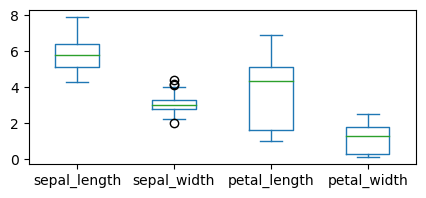

In [161]:
import matplotlib.pyplot as plt
X.plot(kind='box',figsize=(5,2))
plt.show()

In [168]:
X.rolling(5).mean().iloc[4:10] #춧를 부드럽게 보고 싶을 때

,sepal_length,sepal_width,petal_length,petal_width
4,4.86,3.28,1.40,0.20
5,4.92,3.36,1.46,0.24
6,4.86,3.44,1.46,0.26
7,4.92,3.48,1.50,0.26
8,4.88,3.44,1.48,0.26
9,4.86,3.34,1.50,0.24


In [169]:
X.iloc[:10]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


## 8.2 요약통계량

In [170]:
# 1) 기본 요약 통계량
iris.describe() #기본값 => 숫자컬럼에서 요약통계량

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [174]:
iris['species'].describe()
iris.species.describe() #문자열에서의 요약 통계량 : 데이터갯수, 종류(unique), 최빈값(top), 최빈값데이터갯수(freq)

count        150
unique         3
top       setosa
freq          50
Name: species, dtype: object

In [192]:
# 2) describe()의 include와 exclude 매개변수
df=pd.DataFrame({'a':[1,2,3]*2,
                 'b':[1.1,2]*3,
                 'c':['aaa','bbb','aaa','ccc','aaa','bbb'],
                 'd':[True, False]*3})
display(df)
df.info()

,a,b,c,d
0,1,1.1,aaa,True
1,2,2.0,bbb,False
2,3,1.1,aaa,True
3,1,2.0,ccc,False
4,2,1.1,aaa,True
5,3,2.0,bbb,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       6 non-null      int64  
 1   b       6 non-null      float64
 2   c       6 non-null      object 
 3   d       6 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 278.0+ bytes


In [193]:
df.describe() #숫자열만 기본 요약 통계량 return

,a,b
count,6.000000,6.00000
mean,2.000000,1.55000
std,0.894427,0.49295
min,1.000000,1.10000
25%,1.250000,1.10000
50%,2.000000,1.55000
75%,2.750000,2.00000
max,3.000000,2.00000


In [199]:
#include 매개변수를 통해서 요약통계량을 출력 타입 지정

df.describe(include=['int','float','bool'])

,a,b,d
count,6.000000,6.00000,6
unique,NaN,NaN,2
top,NaN,NaN,True
freq,NaN,NaN,3
mean,2.000000,1.55000,NaN
std,0.894427,0.49295,NaN
min,1.000000,1.10000,NaN
25%,1.250000,1.10000,NaN
50%,2.000000,1.55000,NaN
75%,2.750000,2.00000,NaN


In [200]:
#문자형이나 bool의 요약 통계량
df.describe(include=['object','bool'])

,c,d
count,6,6
unique,3,2
top,aaa,True
freq,3,3


In [201]:
#exclude 매개변수를 이용해서 제외할 타입 지정
df.describe(exclude='float')

,a,c,d
count,6.000000,6,6
unique,NaN,3,2
top,NaN,aaa,True
freq,NaN,3,3
mean,2.000000,NaN,NaN
std,0.894427,NaN,NaN
min,1.000000,NaN,NaN
25%,1.250000,NaN,NaN
50%,2.000000,NaN,NaN
75%,2.750000,NaN,NaN


In [202]:
df.describe(include='all') #df의 모든 열의 요약 통계량 출력

,a,b,c,d
count,6.000000,6.00000,6,6
unique,NaN,NaN,3,2
top,NaN,NaN,aaa,True
freq,NaN,NaN,3,3
mean,2.000000,1.55000,NaN,NaN
std,0.894427,0.49295,NaN,NaN
min,1.000000,1.10000,NaN,NaN
25%,1.250000,1.10000,NaN,NaN
50%,2.000000,1.55000,NaN,NaN
75%,2.750000,2.00000,NaN,NaN


In [203]:
df['c'].unique() #특정 컬럼의 고유 값들

array(['aaa', 'bbb', 'ccc'], dtype=object)

In [204]:
df['c'].value_counts() # 고유값들의 빈도(내림차순 정렬)

aaa    3
bbb    2
ccc    1
Name: c, dtype: int64

In [205]:
df.select_dtypes(include=object) # 해당 타입의 컬럼만 추출

,c
0,aaa
1,bbb
2,aaa
3,ccc
4,aaa
5,bbb


In [206]:
df.select_dtypes(exclude=object) #해당 타입의 컬럼만 제외하고 추출

,a,b,d
0,1,1.1,True
1,2,2.0,False
2,3,1.1,True
3,1,2.0,False
4,2,1.1,True
5,3,2.0,False


## 8.3 공분산, 상관계수

In [207]:
#공분산 : (x1-x1의 평균)*(x2-x2의 평균)들의 합을 n-1로 나눈값
X.cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [208]:
X['sepal_length'].var()

0.6856935123042505

In [209]:
# -1<상관계수(공분산/x1의 표준편차*x2의표준편차)<1
X.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


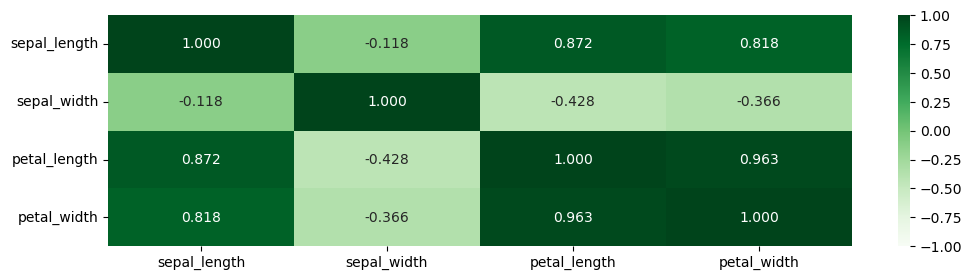

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,3)) # 사이즈 조정
sns.heatmap(X.corr(),annot=True, vmin=-1,vmax=1,cmap='Greens',fmt='.3f')
plt.show()